# SME_Python — Ejemplo de uso

Este notebook muestra cómo instalar y utilizar **SME_Python**, una librería orientada al preprocesamiento y análisis de datasets.

A lo largo del notebook utilizaremos un dataset real de vehículos para mostrar, de forma progresiva, las principales funcionalidades en el paquete.

## Contenido

1. Instalación e importación del paquete
2. Carga y exploración del dataset
3. Discretización de variables
4. Cálculo de métricas
5. Normalización y estandarización
6. Filtrado de variables
7. Correlación e información mutua
8. Visualización de resultados


## Durante la creación del paquete

Se ha intentado mantener un estilo de API publica (ej. discretizar()) que llama a funciones internas (_discretizar_frecuencia) que el usuario no puede ver, haciendo un 'router' interno para segun el caso.

Tambien se ha hecho hincapie en un sistema de printeo de informacion a distintos niveles (_verbose) y se ha intentado tratar de gestionar todos los errores, warnings... mediante el uso de _verbose y raise_error.

## 1. Instalación e importación

En primer lugar instalamos la versión disponible del paquete directamente desde GitHub. De esta forma podemos comprobar que el proyecto puede instalarse correctamente como una librería de Python.

In [1]:
#%pip install "git+https://github.com/EnZaFe/SME_paquetes.git#subdirectory=v_python"
%pip install -e "C:\Users\Burbu\Desktop\SME_Python\v_python"

Obtaining file:///C:/Users/Burbu/Desktop/SME_Python/v_python
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for SME_python (pyproject.toml): started
  Building editable for SME_python (pyproject.toml): finished with status 'done'
  Created wheel for SME_python: filename=sme_python-0.1.2-0.editable-py3-none-any.whl size=1657 sha256=fdbb2fe8e3b202e54861787b3b1d1a43b8db154b8fa0d52bf7917be0e1dd7b5d
  Stored in directory: C:\Users\Burbu\AppData\Local\Temp\pip-ephem-wheel-cache-i0ixbe3j\wheels\ff\93\6d\07674dd55fada7cc328aef33c5308

### Comprobación de la instalación

Comprobamos que el paquete se puede importar correctamente y mostramos la versión instalada.

In [2]:
import SME_python as sme

print(sme.__version__)
print(sme.__file__)

0.1.2
C:\Users\Burbu\Desktop\SME_Python\v_python\src\SME_python\__init__.py


## 2. Dataset

Para probar las funcionalidades de la librería utilizaremos el **Vehicle Dataset from CarDekho** ademas de ciertos dataset incluidos en scikit-learn.

El dataset contiene información sobre vehículos de segunda mano e incluye tanto variables numéricas como categóricas.

Entre las variables disponibles encontramos:
- `name`: nombre del vehículo
- `year`: año del vehículo.
- `selling_price`: precio de venta.
- `km_driven`: kilómetros recorridos.
- `fuel`: tipo de combustible.
- `seller_type`: tipo de vendedor.
- `transmission`: tipo de transmisión.
- `owner`: número de propietarios anteriores.

### Descarga del dataset

Utilizamos `kagglehub` para descargar el dataset directamente desde Kaggle.

In [3]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import pandas as pd
import kagglehub

path = kagglehub.dataset_download(
    "nehalbirla/vehicle-dataset-from-cardekho"
)

print("Dataset descargado en:", path)

Dataset descargado en: C:\Users\Burbu\.cache\kagglehub\datasets\nehalbirla\vehicle-dataset-from-cardekho\versions\4


El dataset descargado contiene varios archivos CSV. Para este ejemplo utilizaremos `car data.csv`, que contiene una versión compacta y adecuada para mostrar las funcionalidades de la librería.

In [5]:
os.listdir(path)

['car data.csv',
 'CAR DETAILS FROM CAR DEKHO.csv',
 'Car details v3.csv',
 'car details v4.csv']

In [6]:
df = pd.read_csv(
    os.path.join(path, "CAR DETAILS FROM CAR DEKHO.csv")
)

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


En caso de que ya tengamos un dataset descargado o queramos hacer pruebas. Podemos utilizar la funcion `load_dataset`, con la que podemos convertir automaticamente a pd.dataframe cualquier archivo de excel o texto. Ademas, nos permite cargar directamente 3 datasets de sklearn: iris, wine y breast_cancer.

In [7]:
df_by_path = sme.load_dataset("CAR DETAILS FROM CAR DEKHO.csv")
print(type(df_by_path))

df_iris = sme.load_dataset("iris")
print(type(df_iris))


Cargando texto delimitado desde 'CAR DETAILS FROM CAR DEKHO.csv'...
Separador detectado: ','
Cargado: 4340 filas x 8 columnas.
<class 'pandas.DataFrame'>
Cargando dataset 'iris'...
Cargado: 150 filas x 5 columnas.
<class 'pandas.DataFrame'>


### Exploración inicial

Antes de aplicar las funciones de `SME_Python`, comprobamos las dimensiones del dataset, sus columnas y los tipos de datos.

In [8]:
df.shape

(4340, 8)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 515.2 KB


## 3. Discretización de variables

La discretización permite transformar variables numéricas continuas en intervalos.

`SME_Python` proporciona dos metodos:

- **Anchura (`anchura`)**: divide el rango de valores en intervalos de igual amplitud.
- **Frecuencia (`frecuencia`)**: construye intervalos intentando mantener una cantidad similar de observaciones en cada uno.

La función también permite seleccionar qué columnas discretizar y controlar el número de intervalos o la frecuencia deseada.

### 3.1. Discretización automática

Si no especificamos las columnas, la función identifica las variables numéricas susceptibles de ser discretizadas.

Si tampoco indicamos el número de intervalos, la función utiliza su criterio predeterminado para determinarlo.

In [10]:
df_discret = sme.discretizar(df)

df_discret.head()

Iniciando discretizacion...
Discretización finalizada correctamente.
Discretización finalizada correctamente.
Discretización finalizada correctamente.


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,"(2006.99, 2007.01)","(56829.49, 60921.66)","(69881.38, 70253.08)",Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,"(2006.99, 2007.01)","(134580.65, 138672.81)","(49809.36, 50181.06)",Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,"(2011.99, 2012.0)","(596995.39, 601087.56)","(99989.42, 100361.12)",Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,"(2016.99, 2017.01)","(249161.29, 253253.46)","(45720.61, 46092.31)",Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,"(2013.99, 2014.0)","(449677.42, 453769.59)","(140876.87, 141248.58)",Diesel,Individual,Manual,Second Owner


### 3.2. Discretización por igual anchura

Podemos seleccionar una variable concreta y especificar el número de intervalos que queremos utilizar.

En este caso dividiremos `km_driven` en 10 intervalos de igual anchura.

In [11]:
df_discret = sme.discretizar(
    df,
    columnas=["km_driven"],
    metodo="anchura",
    n_intervalos=10,
    verbose=2
)

df_discret.head()

Iniciando discretizacion...
Parametros elegidos: 
    metodo: anchura, 
    n_intervalos: 10, 
    frecuenca: None, 
    columnas: ['km_driven']
             
Número de casos: 4340
Mínimo: 1.0
Máximo: 806599.0
Anchura de los intervalos: 80659.8
Límites de los intervalos: [1.0, 80660.8, 161320.6, 241980.4, 322640.2, 403300.0, 483959.8, 564619.6, 645279.4, 725939.2, 806599.0]
Discretización finalizada correctamente.


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,"(1.0, 80660.8)",Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,"(1.0, 80660.8)",Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,"(80660.8, 161320.6)",Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,"(1.0, 80660.8)",Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,"(80660.8, 161320.6)",Diesel,Individual,Manual,Second Owner


### 3.3. Discretización por igual frecuencia

También podemos utilizar el método de igual frecuencia.

En este caso los intervalos se construyen de manera que contengan, aproximadamente, el mismo número de observaciones.

In [12]:
df_discret = sme.discretizar(
    df,
    columnas=["km_driven"],
    metodo="frecuencia",
    n_intervalos=10,
    verbose=2
)

df_discret.head()

Iniciando discretizacion...
Parametros elegidos: 
    metodo: frecuencia, 
    n_intervalos: 10, 
    frecuenca: None, 
    columnas: ['km_driven']
             
Número de casos: 4340
Frecuencia base calculada: 434
Elementos sobrantes: 0
Valores ordenados: [1, 101, 101, 101, 1000, 1000, 1000, 1000, 1000, 1000]
Discretización finalizada correctamente.


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,"(60000.0, 70000.0)",Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,"(40000.0, 50000.0)",Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,"(80000.0, 100000.0)",Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,"(40000.0, 50000.0)",Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,"(120000.0, 806599.0)",Diesel,Individual,Manual,Second Owner


### 3.4. Especificar directamente la frecuencia

Otra posibilidad es indicar directamente cuántas observaciones queremos aproximadamente en cada intervalo.

La función se encarga de calcular automáticamente los límites necesarios.

In [13]:
df_discret = sme.discretizar(
    df,
    columnas=["km_driven"],
    metodo="frecuencia",
    frecuencia=10,
    verbose=1
)

df_discret.head()

Iniciando discretizacion...
Discretización finalizada correctamente.


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,"(68745.0, 70000.0)",Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,"(49824.0, 50000.0)",Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,"(100000.0, 100000.0)",Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,"(46000.0, 46000.0)",Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,"(140000.0, 144000.0)",Diesel,Individual,Manual,Second Owner


## 4. Cálculo de métricas

Una vez que hemos visto cómo transformar las variables, podemos calcular diferentes métricas para estudiar sus características.

Podemos calcular:

- **Entropía** para variables discretas.
- **Varianza** para variables numéricas.
- **AUC** cuando disponemos y asignamos una variable de objetivo binaria, es decir, 2 clases.

Estas métricas pueden utilizarse posteriormente para seleccionar o filtrar variables.

In [14]:
metricas = sme.calcular_metricas(df)

metricas #Aprox. 5s

Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 8 columnas del dataset.
Cálculo de métricas finalizado correctamente.


{'name': {'entropia': 9.805485070072685},
 'year': {'varianza': 17.76503026184405},
 'selling_price': {'varianza': 334641515977.28217},
 'km_driven': {'varianza': 2175170962.4744163},
 'fuel': {'entropia': 1.111502331469174},
 'seller_type': {'entropia': 0.9280578286510033},
 'transmission': {'entropia': 0.47913854005767287},
 'owner': {'entropia': 1.311691389143732}}

También podemos calcular las métricas sobre un conjunto concreto de variables y asignando clases para el calculo de AUC.

In [15]:
metricas = sme.calcular_metricas(
    df,
    clases=df["transmission"]
)

metricas

Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 8 columnas del dataset.
Cálculo de métricas finalizado correctamente.


{'name': {'entropia': 9.805485070072685},
 'year': {'varianza': 17.76503026184405, 'auc': 0.6504267568088387},
 'selling_price': {'varianza': 334641515977.28217, 'auc': 0.8325279189913375},
 'km_driven': {'varianza': 2175170962.4744163, 'auc': 0.6356353692556159},
 'fuel': {'entropia': 1.111502331469174},
 'seller_type': {'entropia': 0.9280578286510033},
 'transmission': {'entropia': 0.47913854005767287},
 'owner': {'entropia': 1.311691389143732}}

## 5. Normalización y estandarización

La librería incluye dos transformaciones habituales para preparar variables numéricas:

- **Normalización**: transforma los valores al rango `[0, 1]`.
- **Estandarización**: transforma los valores para trabajar alrededor de una media de 0 y una desviación estándar de 1.

En ambos casos podemos indicar las variables que queremos transformar.

In [16]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')

In [17]:
df_normalizado = sme.normalizar(
    df,
    atributos=["selling_price", "km_driven"]
)

df_normalizado.head()

Iniciando normalización...
Variable normalizada correctamente.
Variable normalizada correctamente.


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,0.004505,0.086783,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,0.012950,0.061988,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,0.065315,0.123976,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,0.025901,0.057028,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,0.048423,0.174807,Diesel,Individual,Manual,Second Owner


In [18]:
df_estandarizado = sme.estandarizar(
    df,
    atributos=["selling_price", "km_driven"],
)

df_estandarizado.head()

Iniciando estandarización...
Variable estandarizada correctamente.
Variable estandarizada correctamente.


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,-0.767658,0.081130,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,-0.638023,-0.347649,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,0.165712,0.724298,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,-0.439250,-0.433405,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,-0.093557,1.603294,Diesel,Individual,Manual,Second Owner


## 6. Filtrado de variables

Una vez calculadas las métricas podemos utilizarlas para seleccionar variables.

La función `filtrar_variables` permite conservar o descartar variables según un umbral determinado.

El criterio utilizado depende del tipo de variable y de la métrica seleccionada.

Si no se le dan los datos, hace los calculos automaticamente.

In [19]:
df_filtrado = sme.filtrar_variables(
    df,
    entropia=[0.3, 0.4],
    modo="dentro"
)
eliminadas = set(df.columns) - set(df_filtrado.columns)

print("Variables eliminadas:", len(eliminadas))
print(eliminadas)

Iniciando filtrado de variables...
Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 8 columnas del dataset.
Cálculo de métricas finalizado correctamente.
Filtro pasado correctamente.
Variables eliminadas: 5
{'owner', 'name', 'seller_type', 'fuel', 'transmission'}


Se pueden usar como umbrales: la entropia la vaianza y AUC. Se recomienda hacer una normalizacion o estandarizacion antes de utilizar el filtro.

Tambien tiene tanto modo 'dentro' como 'fuera' del rango que se le añada a cada umbral.

Destacar que permite el uso de multiples umbrales al mismo tiempo, donde se aplica discreto a los discretos y numerico a los numericos. AUnque varianza y AUC a la vez hacen and. 

In [20]:
df_filtrado = sme.filtrar_variables(
    df_estandarizado,
    #entropia=[0.3, 0.4],
    varianza=[0.3,0.5],
    modo="dentro",
)
eliminadas = set(df.columns) - set(df_filtrado.columns)

print("Variables eliminadas:", len(eliminadas))
print(eliminadas)

Iniciando filtrado de variables...
Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 8 columnas del dataset.
Cálculo de métricas finalizado correctamente.
Filtro pasado correctamente.
Variables eliminadas: 3
{'year', 'selling_price', 'km_driven'}


De todas maneras se puede hacer en por partes; calculando las metricas fuera y eligiendo los atributos que se desee.

In [21]:
print("----------* CALCULANDO METRICAS *----------")
metricas = sme.calcular_metricas(df_estandarizado)

print("----------* FILTRANDO DATASET *----------")
df_filtrado = sme.filtrar_variables(
    dataset=df_estandarizado,
    #entropia=[0.3, 0.4],
    varianza=[0.3,0.5],
    modo="dentro",
    metricas=metricas,
    verbose=2
)
eliminadas = set(df.columns) - set(df_filtrado.columns)

print("Variables eliminadas:", len(eliminadas))
print(eliminadas)

----------* CALCULANDO METRICAS *----------
Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 8 columnas del dataset.
Cálculo de métricas finalizado correctamente.
----------* FILTRANDO DATASET *----------
Iniciando filtrado de variables...
Filtro pasado correctamente.
Variables eliminadas: 3
{'year', 'selling_price', 'km_driven'}


## 7. Correlación e información mutua

`SME_Python` permite estudiar diferentes tipos de relación entre variables dependiendo de su naturaleza:

- **Pearson** para variables numéricas.
- **Información mutua** para variables categóricas.
- **Welch** para estudiar la relación entre una variable categórica y una numérica.

La función selecciona el cálculo apropiado en función del tipo de variables.

In [22]:
correlaciones = sme.calcular_correlacion(df)

correlaciones[0] # Tambien tenemos los detalles de cada calculo para los graficos

Iniciando cálculo de correlaciones...
Se analizarán 8 atributos.
Calculo de correlaciones finalizado correctamente.


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
name,1.000000,52.893315,2077.396257,48.800514,0.770435,0.420086,0.332114,0.495126
year,52.893315,1.000000,0.413922,-0.419688,26.101335,315.625548,112.571173,473.966458
selling_price,2077.396257,0.413922,1.000000,-0.192289,191.440589,82.332781,274.267189,167.387324
km_driven,48.800514,-0.419688,-0.192289,1.000000,134.709716,146.963203,90.796869,436.136992
fuel,0.770435,26.101335,191.440589,134.709716,1.000000,0.002165,0.003081,0.001979
seller_type,0.420086,315.625548,82.332781,146.963203,0.002165,1.000000,0.020155,0.049824
transmission,0.332114,112.571173,274.267189,90.796869,0.003081,0.020155,1.000000,0.004688
owner,0.495126,473.966458,167.387324,436.136992,0.001979,0.049824,0.004688,1.000000


## 8. Visualización de resultados

Finalmente, la librería incorpora funciones de visualización para representar los resultados de algunos de los análisis anteriores.

Entre ellas encontramos visualizaciones para:

- AUC.
- Correlaciones de Pearson.
- Información mutua.
- Estadísticos de Welch.

ROC · Cómo leerla: al marcar como «Manual» las observaciones de mayor a menor selling price, la curva sube con cada acierto y avanza con cada error. Cuanto más cerca de la esquina superior izquierda, mejor; la diagonal es el azar. Respondes SÍ si AUC ≥ 0.70 (0.5 azar · 0.8 bueno · 0.9 excelente).
Grafico de AUC y distribucion creados correctamente.


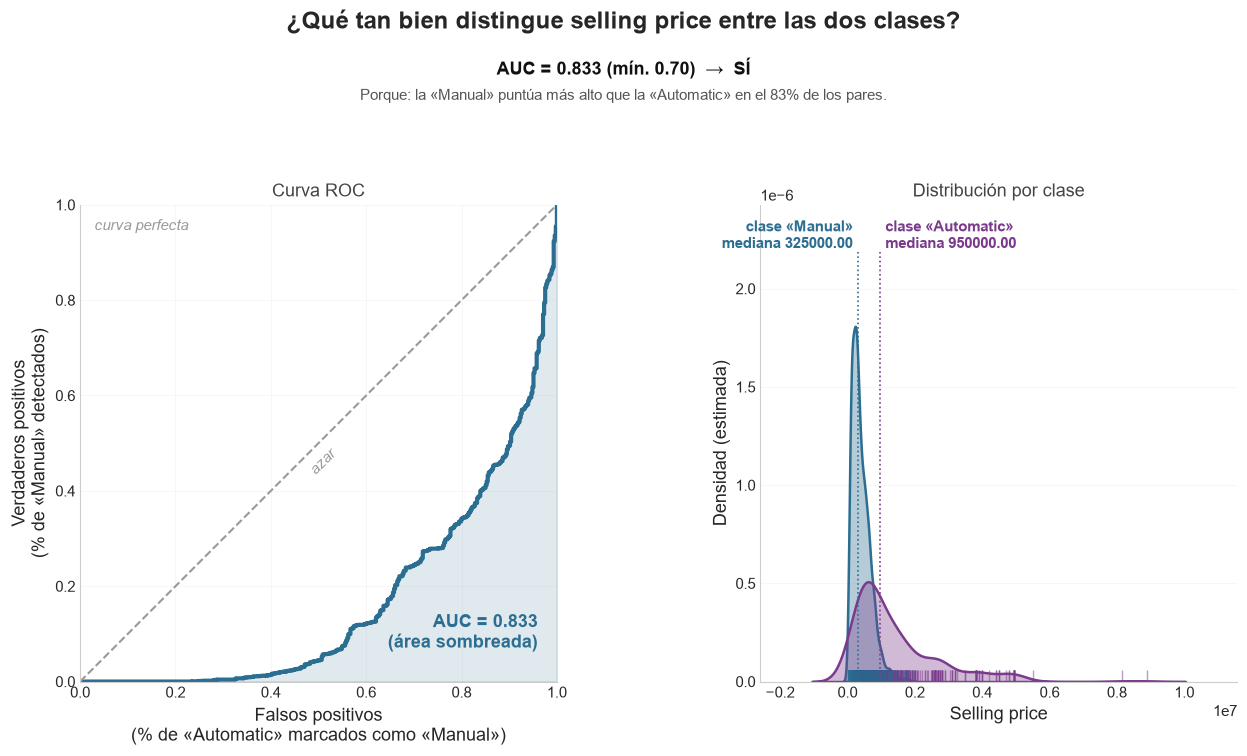

In [23]:
fig = sme.graficar_auc(
    df["selling_price"],
    df["transmission"]
)

En los textos del grafico vemos un AUC positivo y un SI a la pregunta. mientras que la ilustracion ensi, enseña una curva muy por debajo del azar. Eso demuestra una clasificacion invertida y por tanto correcta, inversamente.

Intenetaremos multiplicar el atributo numerico *-1.

ROC · Cómo leerla: al marcar como «Manual» las observaciones de mayor a menor selling price, la curva sube con cada acierto y avanza con cada error. Cuanto más cerca de la esquina superior izquierda, mejor; la diagonal es el azar. Respondes SÍ si AUC ≥ 0.70 (0.5 azar · 0.8 bueno · 0.9 excelente).
Grafico de AUC y distribucion creados correctamente.


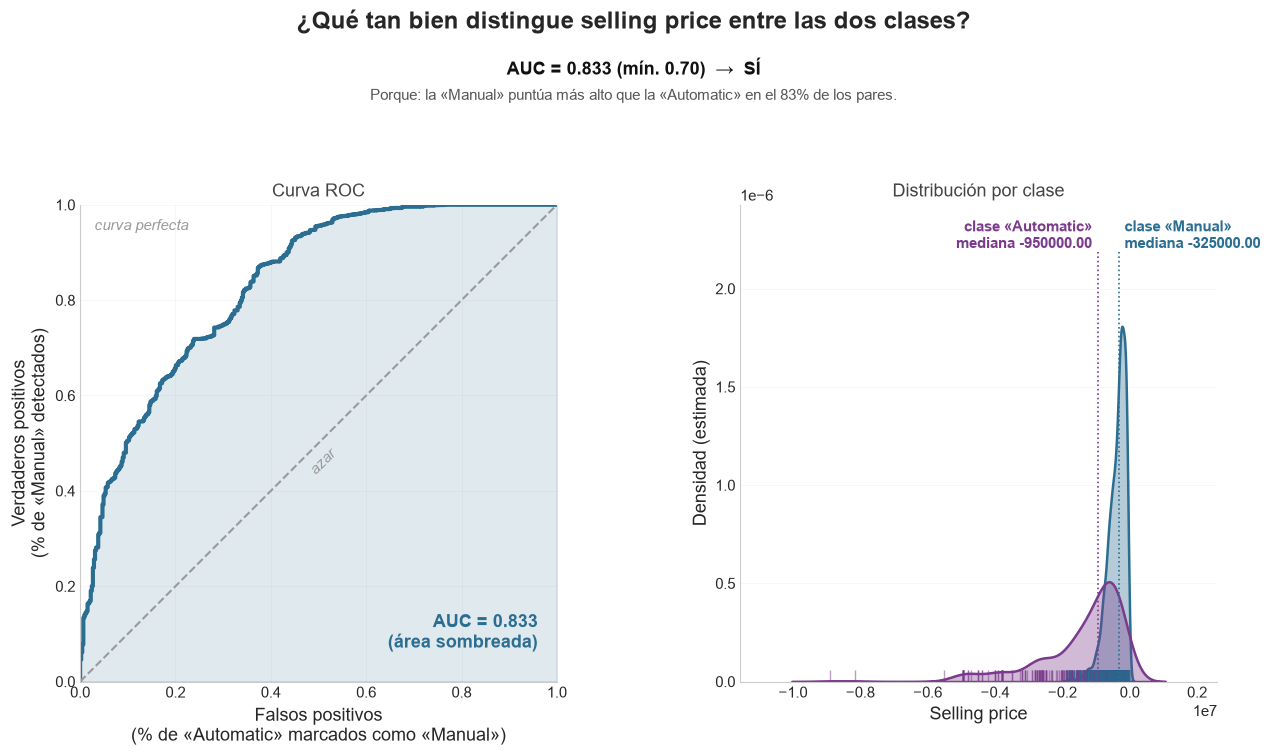

In [24]:
fig = sme.graficar_auc(
    df["selling_price"] *-1,
    df["transmission"]
)

Recordemos, Selling_Price es el precio al que quiere venderlo el dueño, Present_price es el precio que tenia en el concesionario.

In [25]:

# Si no tenemos los resultados los calculara automaticamente
fig1 = sme.graficar_pearson(
    df["km_driven"],
    df["selling_price"]
)
#Si los tenemos nosotros podemos meterlos directamente
resultado = sme.calcular_correlacion(
    df,
    atributos=["km_driven", "selling_price"]
)

fig2 = sme.graficar_pearson(
    df["km_driven"],
    df["selling_price"],
    resultado=resultado[1][("km_driven","selling_price")]
)


Pearson · Cómo leerlo: cada punto es una observación; la recta es el ajuste lineal y la banda, ±1 desviación del error. Respondes SÍ si |r| ≥ 0.5 y p < 0.05 (|r|: 0.3 débil · 0.5 moderada · 0.7 fuerte).
Grafico pearson creado correctamente.
Iniciando cálculo de correlaciones...
Se analizarán 2 atributos.
Calculo de correlaciones finalizado correctamente.
Pearson · Cómo leerlo: cada punto es una observación; la recta es el ajuste lineal y la banda, ±1 desviación del error. Respondes SÍ si |r| ≥ 0.5 y p < 0.05 (|r|: 0.3 débil · 0.5 moderada · 0.7 fuerte).
Grafico pearson creado correctamente.


Veamos los dos graficos uno al lado del otro...


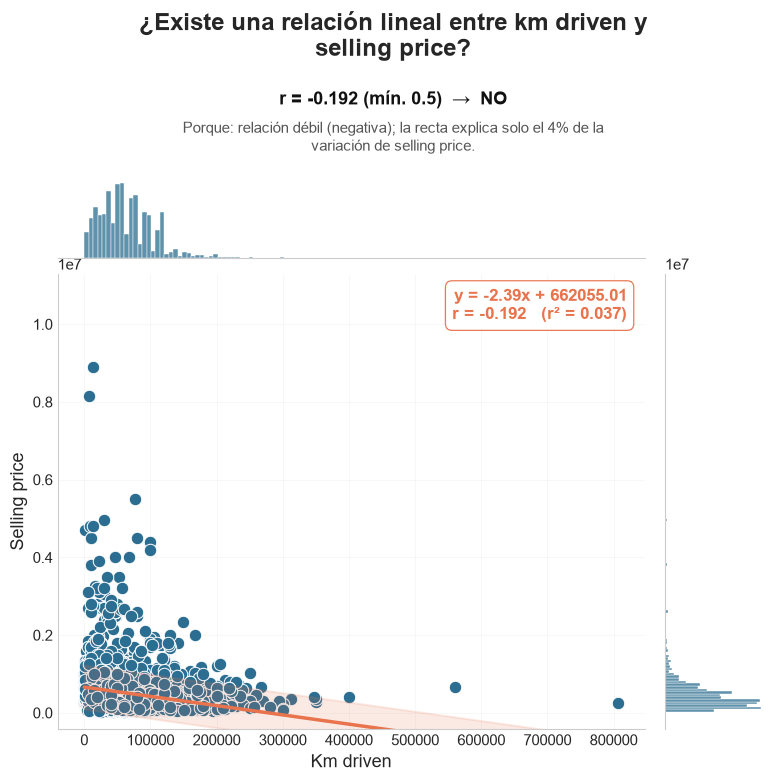
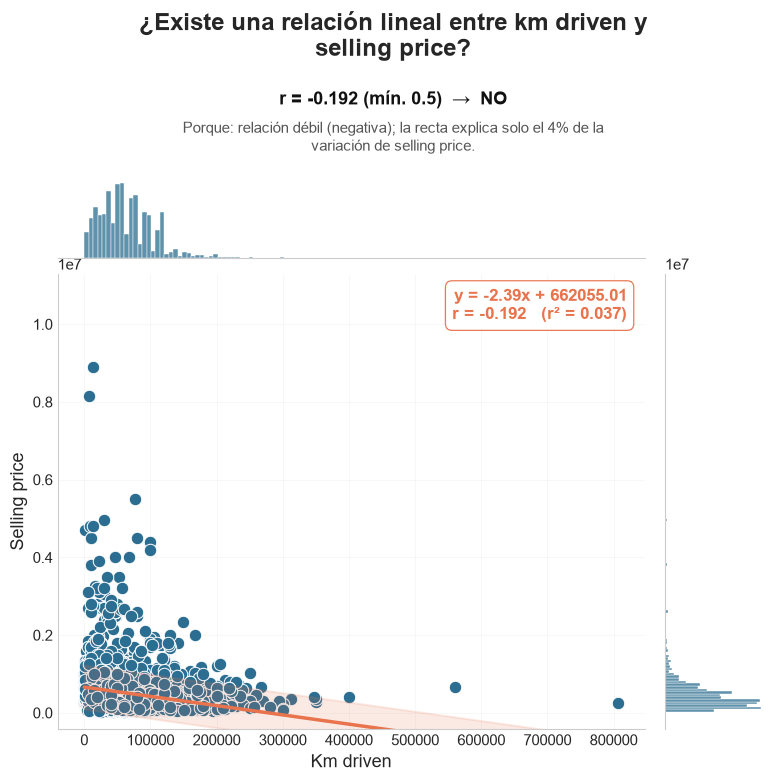

In [26]:
from io import BytesIO
from IPython.display import display, HTML
import base64

def figura_a_base64(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    buffer.seek(0)
    return base64.b64encode(buffer.read()).decode()

img1 = figura_a_base64(fig1)
img2 = figura_a_base64(fig2)

display(HTML(f"""
<div style="display:flex; gap:20px;">
    <img src="data:image/png;base64,{img1}" style="width:48%;">
    <img src="data:image/png;base64,{img2}" style="width:48%;">
</div>
"""))

Vemos como aunque a priori diriamos que más kilometros significa mas barato, hay suficiente ruido de gamaas distintas... que no se puede y mirando misma gama o mismo tipo de coche si existiria la relacion.

Información mutua · Cómo leerla: cada celda cuenta las observaciones de esa combinación; si las filas se reparten de forma muy distinta, las variables están relacionadas. Respondes SÍ si la prueba G da p < 0.05 (MI mayor que la del azar; en bits no hay un umbral universal).
Aviso: hay celdas con menos de 5 casos esperados; la prueba G es orientativa.
Grafico de información mutua creado correctamente.


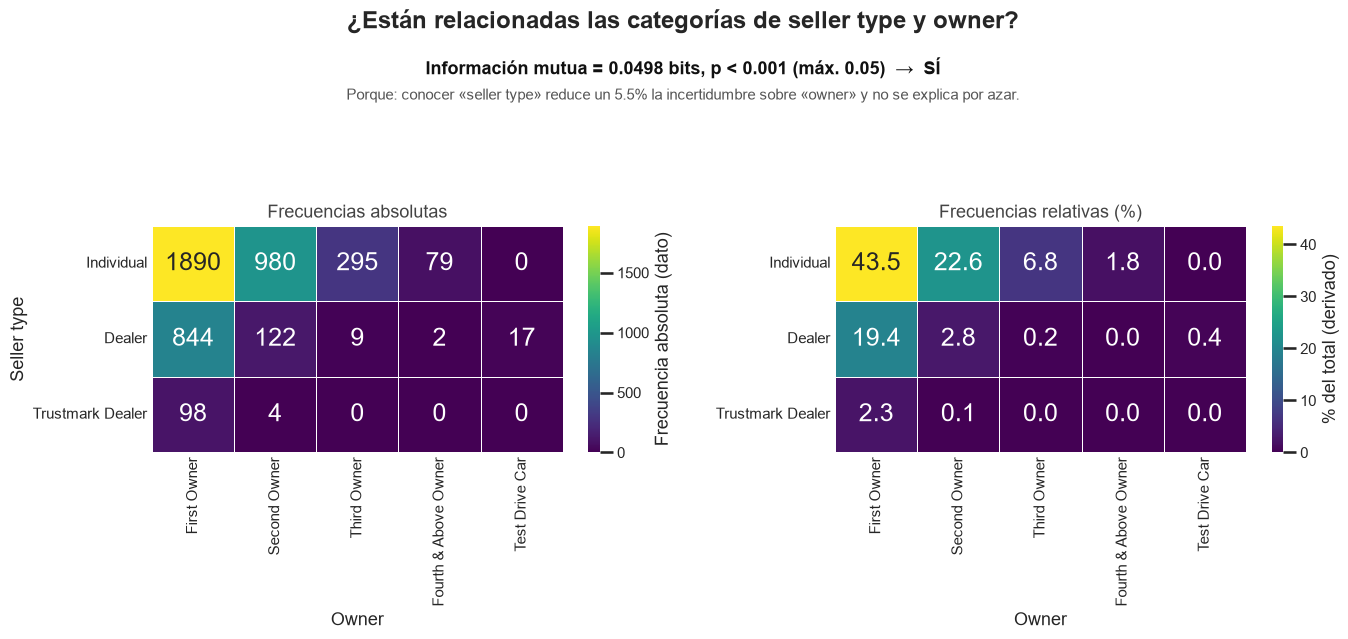

In [27]:
fig = sme.graficar_informacion_mutua(
    df["seller_type"],
    df["owner"]
)

Podemos ver como estadisticamente si hay relacion, y a simple bista vemos como los dueños que son individuos, venden coches de segunda, tercera, incluso mas, minetnras que los concesionarios no lo hacen.

No se ha proporcionado el resultado de Welch ANOVA. Se calculará automáticamente.
Welch ANOVA · Cómo leerlo: caja = 50% central del grupo, puntos = observaciones, rombo = media del grupo, línea gris = media general. Respondes SÍ si p < 0.05 (diferencias tan grandes serían raras si los grupos fueran iguales).
Grafico welch creado correctamente.


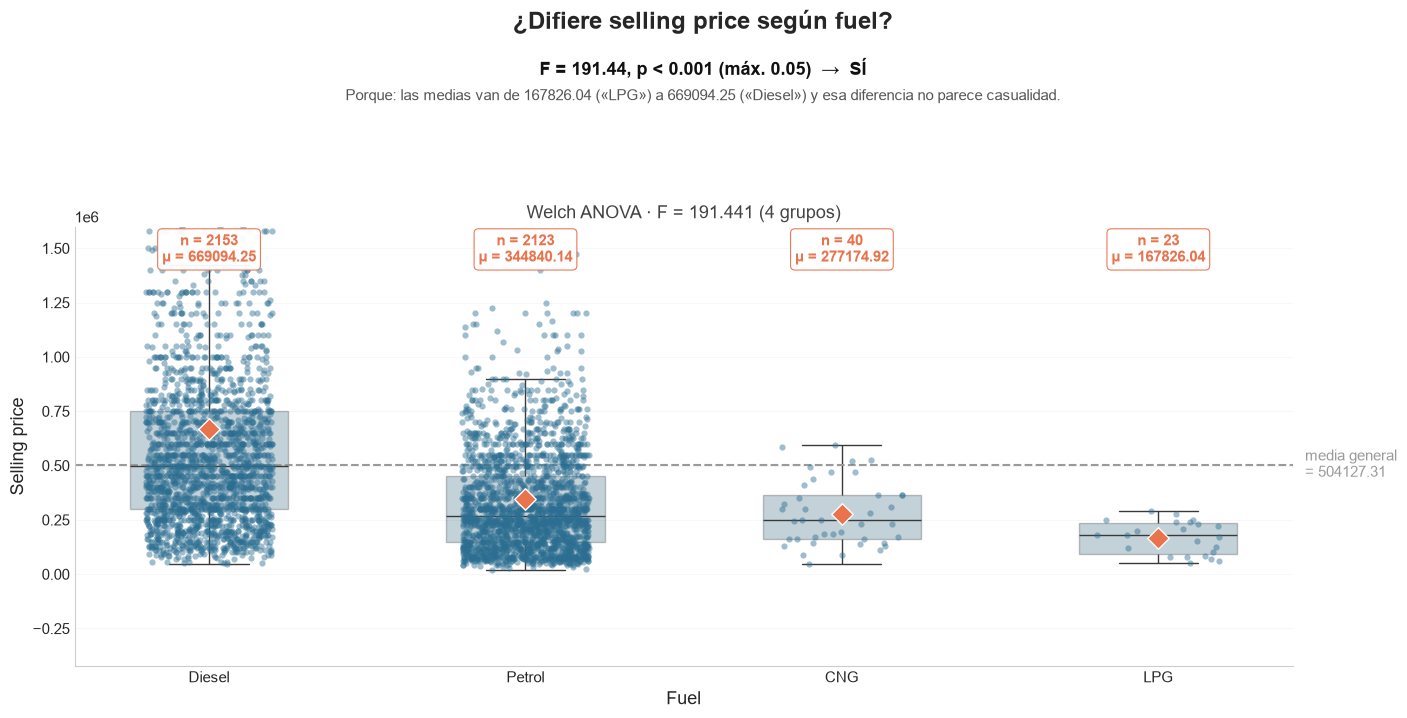

In [28]:
fig = sme.graficar_welch(
    df["fuel"],
    df["selling_price"],
    verbose=3,
    limite_y=1600000
)

Vemos como de media, y en boxplots.

## Conclusión

A lo largo de este notebook hemos visto las principales funcionalidades de `SME_Python`, desde la preparación de los datos hasta el cálculo de métricas, transformación y selección de variables, análisis de relaciones y visualización de resultados.